<a href="https://www.kaggle.com/code/salemali7/housingpricepredictionmachinelearningmodels?scriptVersionId=324951119" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

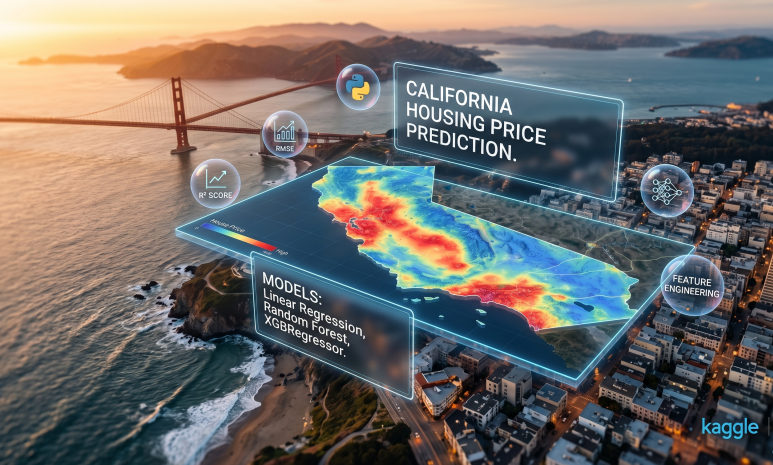

# California Housing Price Prediction using Machine Learning Models

## Notebook Description
This notebook focuses on predicting California house prices using multiple machine learning models.
We perform full data preprocessing, feature engineering, visualization, and model comparison including:
* Linear Regression
* Polynomial Regression
* Random Forest
* XGBoost

The goal is to understand how different features affect house prices and compare model performance using evaluation metrics like RMSE, MAE, and R² score.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import plot_tree
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE,BorderlineSMOTE,ADASYN
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error


# help(RandomForestClassifier)

##  Step 1 - Import Libraries

In this step, we import all required libraries for data analysis, visualization, preprocessing, and machine learning models.

We use:
- Pandas & NumPy for data handling
- Matplotlib & Seaborn for visualization
- Scikit-learn for ML models and preprocessing
- XGBoost for advanced boosting model

### About this file 

<small>

1. **longitude:** A measure of how far west a house is; a higher value is farther west
2. **latitude:** A measure of how far north a house is; a higher value is farther north
3. **housingMedianAge:** Median age of a house within a block; a lower number is a newer building
4. **totalRooms:** Total number of rooms within a block
5. **totalBedrooms:** Total number of bedrooms within a block
6. **population:** Total number of people residing within a block
7. **households:** Total number of households, a group of people residing within a home unit, for a block
8. **medianIncome:** Median income for households within a block of houses (measured in tens of thousands of US Dollars)
9. **medianHouseValue:** Median house value for households within a block (measured in US Dollars)
10. **oceanProximity:** Location of the house w.r.t ocean/sea

</small>

## Step 2 - Load Dataset

Here we load the California housing dataset and check its size and first rows.

This helps us understand:
- Number of samples
- Feature structure
- Target variable (median_house_value)

In [2]:
df=pd.read_csv('/kaggle/input/datasets/camnugent/california-housing-prices/housing.csv')
print('DataSet Size', len(df['longitude']))
df.head(9)

DataSet Size 20640


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
5,-122.25,37.85,52.0,919.0,213.0,413.0,193.0,4.0368,269700.0,NEAR BAY
6,-122.25,37.84,52.0,2535.0,489.0,1094.0,514.0,3.6591,299200.0,NEAR BAY
7,-122.25,37.84,52.0,3104.0,687.0,1157.0,647.0,3.1200,241400.0,NEAR BAY
8,-122.26,37.84,42.0,2555.0,665.0,1206.0,595.0,2.0804,226700.0,NEAR BAY


## Step 3 - Handle Missing Values

We check for missing values in the dataset.

Then we remove rows with missing values to keep the dataset clean and avoid bias or errors in training.

In [3]:
print(df.isnull().sum())

df=df.dropna()
print('\nThe max colomn with counts of NULLs is:',df.isnull().sum().max())

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

The max colomn with counts of NULLs is: 0


## Step 4 - Feature Transformation

We apply log transformation to skewed numerical features such as:
- total_rooms
- total_bedrooms
- population
- households

This reduces skewness and helps models learn better patterns.

In [4]:
df.info()
cols = ['total_rooms', 'total_bedrooms', 'population', 'households']

for col in cols:
    df[col] = np.log1p(df[col]) 

<class 'pandas.core.frame.DataFrame'>
Index: 20433 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20433 non-null  float64
 1   latitude            20433 non-null  float64
 2   housing_median_age  20433 non-null  float64
 3   total_rooms         20433 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20433 non-null  float64
 6   households          20433 non-null  float64
 7   median_income       20433 non-null  float64
 8   median_house_value  20433 non-null  float64
 9   ocean_proximity     20433 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.7+ MB


##  Step 5 - Data Visualization

We plot histograms for all features to understand their distribution.

This helps us:
- Detect skewed features
- Understand data spread
- Identify potential outliers

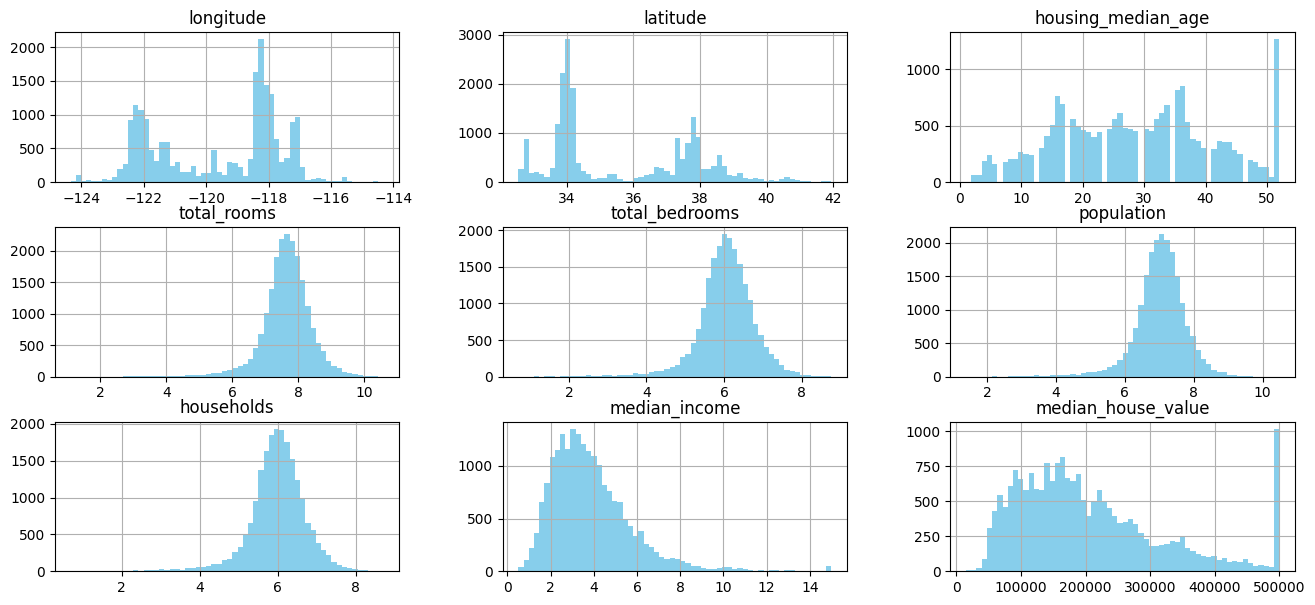

In [5]:
df.hist(bins=60,color='skyblue',figsize=(16,7))
plt.show()


In [6]:
df['ocean_proximity'].unique()

array(['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND'],
      dtype=object)

## Step 6 - Encode Categorical Feature

We convert the categorical column `ocean_proximity` into numerical format using One-Hot Encoding.

This is necessary because machine learning models cannot work with text directly.

In [7]:
# df['ocean_proximity']=df['ocean_proximity'].map({'NEAR BAY':1, '<1H OCEAN':2, 'INLAND':3, 'NEAR OCEAN':4, 'ISLAND':5})

df=pd.get_dummies(df, columns=['ocean_proximity'], drop_first=True)
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,6.781058,4.867534,5.777652,4.844187,8.3252,452600.0,False,False,True,False
1,-122.22,37.86,21.0,8.867850,7.009409,7.784057,7.037906,8.3014,358500.0,False,False,True,False
2,-122.24,37.85,52.0,7.291656,5.252273,6.208590,5.181784,7.2574,352100.0,False,False,True,False
3,-122.25,37.85,52.0,7.150701,5.463832,6.326149,5.393628,5.6431,341300.0,False,False,True,False
4,-122.25,37.85,52.0,7.395108,5.638355,6.338594,5.560682,3.8462,342200.0,False,False,True,False


##  Step 7 - Correlation Heatmap

We visualize correlations between features using a heatmap.

This helps us:
- Understand relationships between variables
- Detect highly correlated features
- Identify features that influence house price

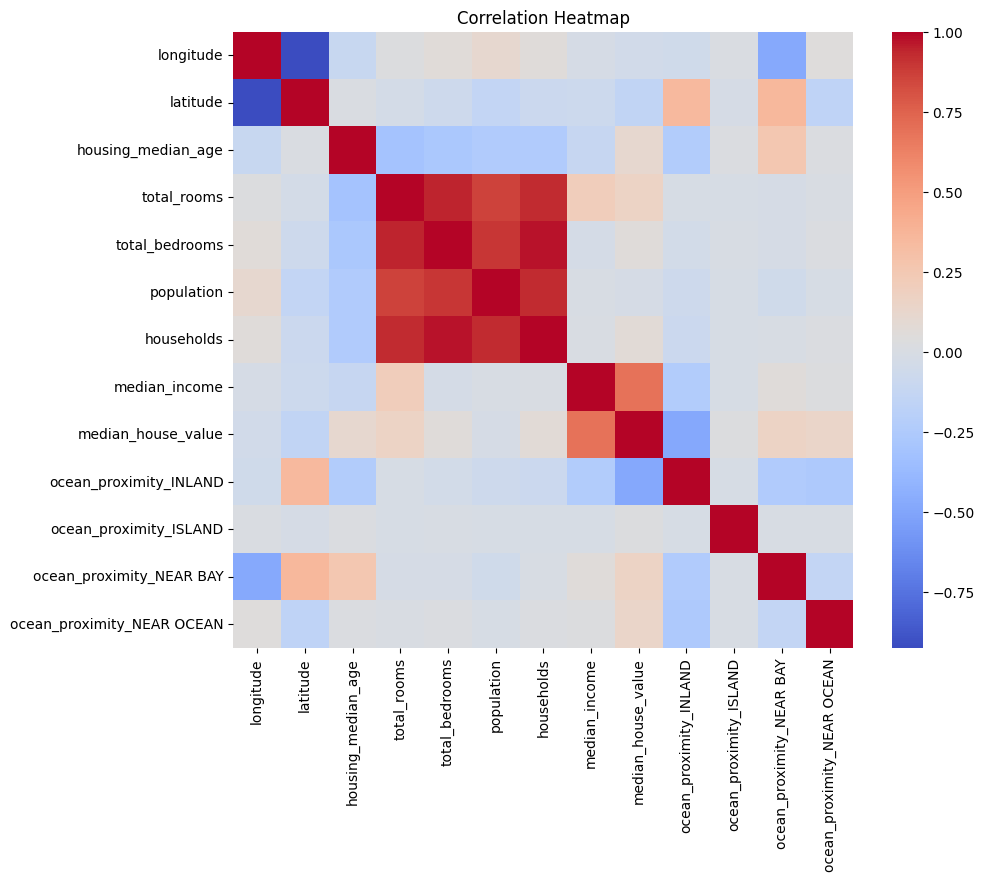

In [8]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

## Step 8 - Feature Engineering

We create new features to improve model performance:

- rooms_per_household
- bedrooms_per_room
- population_per_household

These features provide better insight into housing structure.

In [9]:
df['rooms_per_household'] = df['total_rooms'] / df['households']
df['bedrooms_per_room'] = df['total_bedrooms'] / df['total_rooms']
df['population_per_household'] = df['population'] / df['households']
True

True

## Step 9 - Train-Test Split

We split the dataset into training and testing sets:

- Training set: 80%
- Testing set: 20%

In [10]:
x=df.drop('median_house_value',axis=1)
y=df['median_house_value']
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.2,random_state=42)

# Polynomial Regression

We apply Polynomial Regression with degree 2.

Steps:
- Standardize features
- Transform features into polynomial form
- Train Linear Regression model

We evaluate using:
- MSE
- RMSE
- MAE
- R² Score

Time := 0.20  seconds


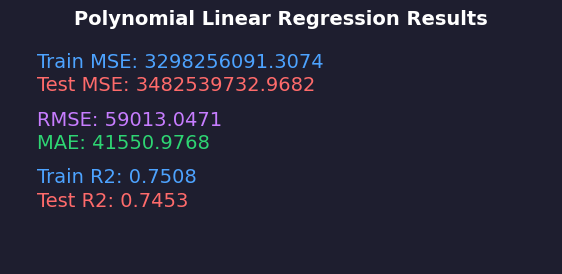


Polynomial Regression Results

The Predicted results of Unseen Data: 

---------------------------------------|
Predicted: 200560.66 , Actual: 245800.00
Predicted: 155359.72 , Actual: 137900.00
Predicted: 201800.81 , Actual: 218200.00
Predicted: 103407.73 , Actual: 220800.00
Predicted: 172972.01 , Actual: 170500.00
Predicted: 59461.98 , Actual: 75000.00
Predicted: 273849.15 , Actual: 269400.00
Predicted: 245661.46 , Actual: 228900.00
Predicted: 451630.03 , Actual: 500001.00
Predicted: 59477.57 , Actual: 80800.00
Predicted: 213315.89 , Actual: 170000.00
Predicted: 87578.03 , Actual: 87800.00
Predicted: 235090.95 , Actual: 242200.00
Predicted: 114269.82 , Actual: 165500.00
Predicted: 95252.83 , Actual: 164000.00
Predicted: 143778.87 , Actual: 238000.00
Predicted: 245764.20 , Actual: 283300.00
Predicted: 307504.61 , Actual: 249400.00
Predicted: 180604.27 , Actual: 143600.00
Predicted: 334495.09 , Actual: 333100.00


In [11]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler
starttime=time.perf_counter()


# ------------------------------------------]||
scaler = StandardScaler()
xtrain_scaled = scaler.fit_transform(xtrain)
xtest_scaled = scaler.transform(xtest)

starttime=time.perf_counter()

pol=PolynomialFeatures(degree=2)

xtrainpol=pol.fit_transform(xtrain_scaled)
xtestpol = pol.transform(xtest_scaled)





modelPR=LinearRegression()


modelPR.fit(xtrainpol, ytrain)

# get the predited answer
train_predictions = modelPR.predict(xtrainpol)
test_predictions =modelPR.predict(xtestpol)


# Cheak the error 
train_mse = mean_squared_error(ytrain, train_predictions)
test_mse = mean_squared_error(ytest, test_predictions)
test_rmse=np.sqrt(test_mse)
test_mae = mean_absolute_error(ytest, test_predictions)
train_r2 = r2_score(ytrain, train_predictions)
test_r2 = r2_score(ytest, test_predictions)



print('Time :=',format(time.perf_counter()-starttime,'.2f'),' seconds')
plt.figure(figsize=(7,3), facecolor='#1E1E2F')
ax = plt.gca()
ax.set_facecolor('#1E1E2F')
plt.axis('off')

plt.title('Polynomial Linear Regression Results', fontsize=14, fontweight='bold', color='white')

style = dict(fontsize=14, ha='left')

plt.text(0.05, 0.85, f"Train MSE: {train_mse:.4f}", color='#4DA3FF', **style)
plt.text(0.05, 0.75, f"Test MSE: {test_mse:.4f}", color='#FF6B6B', **style)
plt.text(0.05, 0.60, f"RMSE: {test_rmse:.4f}", color='#C77DFF', **style)
plt.text(0.05, 0.50, f"MAE: {test_mae:.4f}", color='#2ED573', **style)
plt.text(0.05, 0.35, f"Train R2: {train_r2:.4f}", color='#4DA3FF', **style)
plt.text(0.05, 0.25, f"Test R2: {test_r2:.4f}", color='#FF6B6B', **style)

plt.show()


print('\nPolynomial Regression Results')
print('\nThe Predicted results of Unseen Data: \n')
print('---------------------------------------|')
for i in range(20):
    print('Predicted:', format(test_predictions[i],'.2f'), ', Actual:',  format(ytest.iloc[i],'.2f'))

## Display Actual vs. Predicted Price Polynomial Regression

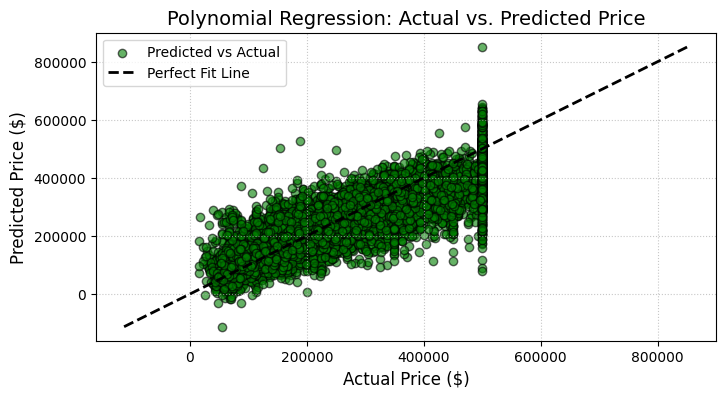

In [12]:
plt.figure(figsize=(8, 4))

plt.scatter(ytrain, train_predictions, alpha=0.6, color='green', edgecolor='k', label='Predicted vs Actual')

min_val = min(ytrain.min(), train_predictions.min())
max_val = max(ytrain.max(), train_predictions.max())
plt.plot([min_val, max_val], [min_val, max_val], color='black', linestyle='--', linewidth=2, label='Perfect Fit Line')

plt.title('Polynomial Regression: Actual vs. Predicted Price', fontsize=14)
plt.xlabel('Actual Price ($)', fontsize=12)
plt.ylabel('Predicted Price ($)', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

# XGBoost Regressor

We train an XGBoost model with tuned hyperparameters.


In [13]:
from sklearn.model_selection import GridSearchCV
parm={
    'n_estimators':[150,300],
    'max_depth':[7,8],
    'learning_rate':[0.2,0.05],
    'gamma':[0.1,0.2,0.3]
}

grid=GridSearchCV(
    XGBRegressor(random_state=42),
    parm,
    cv=5,
    n_jobs=-1,
    scoring='r2'
)
ggg={'gamma': 0.1, 'learning_rate': 0.05, 'max_depth': 8, 'n_estimators': 300}
# grid.fit(xtrain,ytrain)
# ggg=grid.best_params_
# print(ggg)
# print(grid.best_score_)

Time := 2.27  seconds


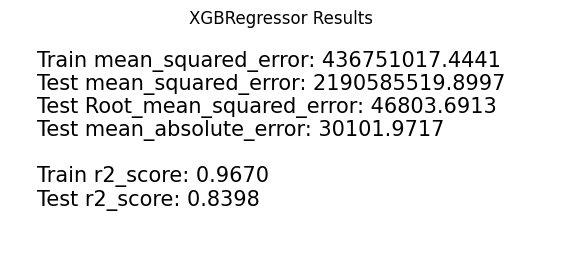


XGBRegressor Results

The Predicted results of Unseen Data: 

---------------------------------------|
Predicted: 228901.89 , Actual: 245800.00
Predicted: 141072.91 , Actual: 137900.00
Predicted: 188857.58 , Actual: 218200.00
Predicted: 120193.02 , Actual: 220800.00
Predicted: 140183.75 , Actual: 170500.00
Predicted: 58751.03 , Actual: 75000.00
Predicted: 265073.16 , Actual: 269400.00
Predicted: 209483.38 , Actual: 228900.00
Predicted: 491223.78 , Actual: 500001.00
Predicted: 72950.77 , Actual: 80800.00


In [14]:
starttime=time.perf_counter()

modelX=XGBRegressor(
                              **ggg,
                              n_jobs=-1,
                              random_state=42,
    )

modelX.fit(xtrain,ytrain)
train_predictions = modelX.predict(xtrain)
test_predictions =modelX.predict(xtest)

train_mse = mean_squared_error(ytrain, train_predictions)
test_mse = mean_squared_error(ytest, test_predictions)
test_mae = mean_absolute_error(ytest, test_predictions)
test_rmse=np.sqrt(test_mse)
train_r2 = r2_score(ytrain, train_predictions)
test_r2 = r2_score(ytest, test_predictions)

print('Time :=',format(time.perf_counter()-starttime,'.2f'),' seconds')
plt.figure(figsize=(7,3))
plt.axis('off')
plt.title('XGBRegressor Results')
plt.text(0.05, 0.85, f"Train mean_squared_error: {train_mse  :.4f}", fontsize=15, ha='left')
plt.text(0.05, 0.75, f"Test mean_squared_error: { test_mse :.4f}", fontsize=15, ha='left')
plt.text(0.05, 0.65, f"Test Root_mean_squared_error: {test_rmse  :.4f}", fontsize=15, ha='left')
plt.text(0.05, 0.55, f"Test mean_absolute_error: { test_mae :.4f}", fontsize=15, ha='left')
plt.text(0.05, 0.35, f"Train r2_score: {train_r2 :.4f}", fontsize=15, ha='left')
plt.text(0.05, 0.25, f"Test r2_score: {test_r2 :.4f}", fontsize=15, ha='left')
plt.show()

print('\nXGBRegressor Results')
print('\nThe Predicted results of Unseen Data: \n')
print('---------------------------------------|')
for i in range(10):
    print('Predicted:', format(test_predictions[i],'.2f'), ', Actual:',  format(ytest.iloc[i],'.2f'))

## show Features Importance

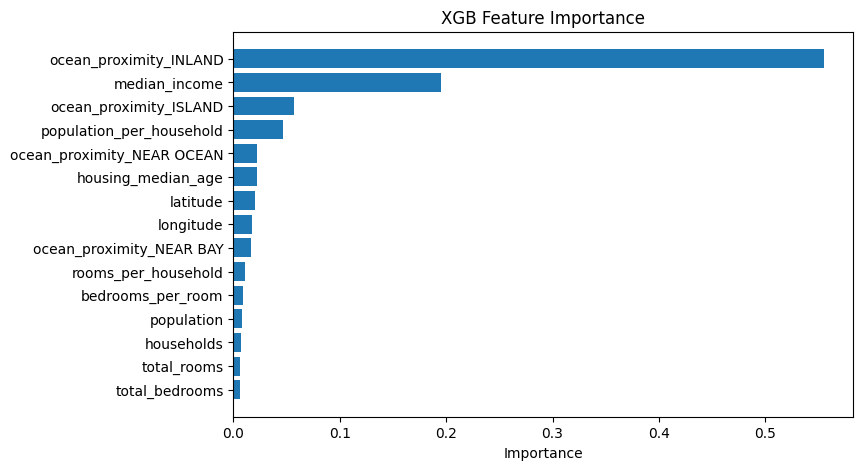

In [15]:
feature_importance = pd.DataFrame({
    'Feature': xtrain.columns,
    'Importance': modelX.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8,5))
plt.barh(feature_importance['Feature'], feature_importance['Importance'])
plt.gca().invert_yaxis()
plt.xlabel('Importance')
plt.title('XGB Feature Importance')
plt.show()

# Random Forest Regressor
- Reduce overfitting
- Improve stability
- Capture non-linear relationships

Time := 0.61  seconds


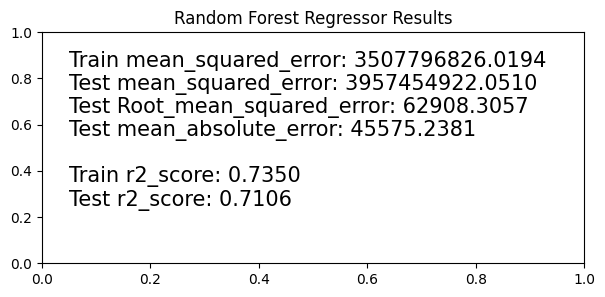


Random Forest Regressor Results

The Predicted results of Unseen Data: 

---------------------------------------|
Predicted: 208496.50 , Actual: 245800.00
Predicted: 156815.98 , Actual: 137900.00
Predicted: 202423.73 , Actual: 218200.00
Predicted: 162659.13 , Actual: 220800.00
Predicted: 150079.15 , Actual: 170500.00
Predicted: 90103.15 , Actual: 75000.00
Predicted: 265783.86 , Actual: 269400.00
Predicted: 223038.21 , Actual: 228900.00
Predicted: 426411.14 , Actual: 500001.00
Predicted: 87446.91 , Actual: 80800.00


In [16]:
starttime=time.perf_counter()

modelR=RandomForestRegressor(
                              max_depth=7,
                              n_jobs=-1,
                              n_estimators=50,
                              max_features='sqrt',
                              random_state=42,
                              min_samples_split=5,
    )

modelR.fit(xtrain,ytrain)
train_predictions = modelR.predict(xtrain)
test_predictions =modelR.predict(xtest)

train_mse = mean_squared_error(ytrain, train_predictions)
test_mse = mean_squared_error(ytest, test_predictions)
test_rmse=np.sqrt(test_mse)
test_mae = mean_absolute_error(ytest, test_predictions)
train_r2 = r2_score(ytrain, train_predictions)
test_r2 = r2_score(ytest, test_predictions)

print('Time :=',format(time.perf_counter()-starttime,'.2f'),' seconds')
plt.figure(figsize=(7,3))
plt.title('Random Forest Regressor Results')
plt.text(0.05, 0.85, f"Train mean_squared_error: {train_mse  :.4f}", fontsize=15, ha='left')
plt.text(0.05, 0.75, f"Test mean_squared_error: { test_mse :.4f}", fontsize=15, ha='left')
plt.text(0.05, 0.65, f"Test Root_mean_squared_error: {test_rmse  :.4f}", fontsize=15, ha='left')
plt.text(0.05, 0.55, f"Test mean_absolute_error: { test_mae :.4f}", fontsize=15, ha='left')
plt.text(0.05, 0.35, f"Train r2_score: {train_r2 :.4f}", fontsize=15, ha='left')
plt.text(0.05, 0.25, f"Test r2_score: {test_r2 :.4f}", fontsize=15, ha='left')
plt.show()


print('\nRandom Forest Regressor Results')
print('\nThe Predicted results of Unseen Data: \n')
print('---------------------------------------|')
for i in range(10):
    print('Predicted:', format(test_predictions[i],'.2f'), ', Actual:',  format(ytest.iloc[i],'.2f'))

## show Features Importance

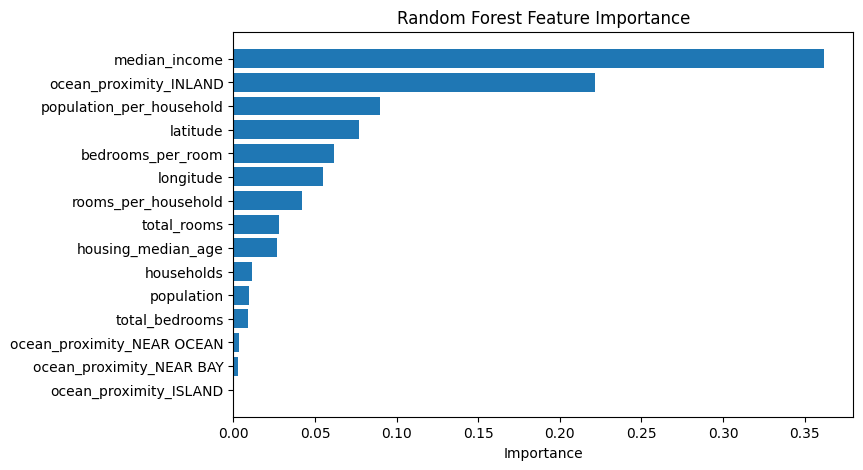

In [17]:
feature_importance = pd.DataFrame({
    'Feature': xtrain.columns,
    'Importance': modelR.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8,5))
plt.barh(feature_importance['Feature'], feature_importance['Importance'])
plt.gca().invert_yaxis()
plt.xlabel('Importance')
plt.title('Random Forest Feature Importance')
plt.show()

# Linear Regression

We apply standard Linear Regression after scaling features.

Time := 0.04  seconds


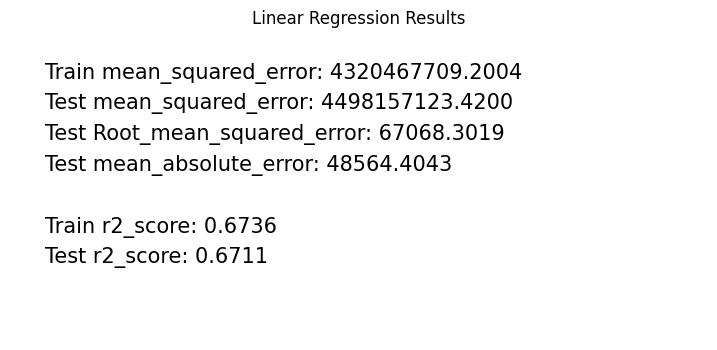


Linear Regression Results

The Predicted results of Unseen Data: 

---------------------------------------|
Predicted: 231875.74 , Actual: 245800.00
Predicted: 148435.81 , Actual: 137900.00
Predicted: 208404.62 , Actual: 218200.00
Predicted: 171100.63 , Actual: 220800.00
Predicted: 226541.12 , Actual: 170500.00
Predicted: 74943.26 , Actual: 75000.00
Predicted: 286047.26 , Actual: 269400.00
Predicted: 252694.25 , Actual: 228900.00
Predicted: 384461.95 , Actual: 500001.00
Predicted: 66189.92 , Actual: 80800.00


In [18]:
from sklearn.preprocessing import StandardScaler
starttime=time.perf_counter()
# ------------------------------------------]||
scaler = StandardScaler()
xtrain_scaled = scaler.fit_transform(xtrain)
xtest_scaled = scaler.transform(xtest)


modelLR=LinearRegression()
modelLR.fit(xtrain_scaled,ytrain)


# get the predited answer
train_predictions = modelLR.predict(xtrain_scaled)
test_predictions =modelLR.predict(xtest_scaled)






train_mse = mean_squared_error(ytrain, train_predictions)
test_mse = mean_squared_error(ytest, test_predictions)
test_rmse=np.sqrt(test_mse)
test_mae = mean_absolute_error(ytest, test_predictions)
train_r2 = r2_score(ytrain, train_predictions)
test_r2 = r2_score(ytest, test_predictions)

print('Time :=',format(time.perf_counter()-starttime,'.2f'),' seconds')
plt.figure(figsize=(9,4))
plt.axis('off')
plt.title('Linear Regression Results')
plt.text(0.05, 0.85, f"Train mean_squared_error: {train_mse  :.4f}", fontsize=15, ha='left')
plt.text(0.05, 0.75, f"Test mean_squared_error: { test_mse :.4f}", fontsize=15, ha='left')
plt.text(0.05, 0.65, f"Test Root_mean_squared_error: {test_rmse  :.4f}", fontsize=15, ha='left')
plt.text(0.05, 0.55, f"Test mean_absolute_error: { test_mae :.4f}", fontsize=15, ha='left')
plt.text(0.05, 0.35, f"Train r2_score: {train_r2 :.4f}", fontsize=15, ha='left')
plt.text(0.05, 0.25, f"Test r2_score: {test_r2 :.4f}", fontsize=15, ha='left')
plt.show()


print('\nLinear Regression Results')
print('\nThe Predicted results of Unseen Data: \n')
print('---------------------------------------|')
for i in range(10):
    print('Predicted:', format(test_predictions[i],'.2f'), ', Actual:',  format(ytest.iloc[i],'.2f'))

## Display Actual vs. Predicted Price Linear Regression

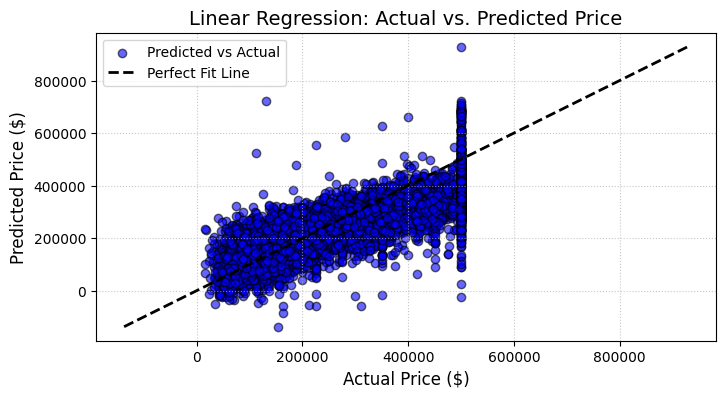

In [19]:
plt.figure(figsize=(8, 4))

plt.scatter(ytrain, train_predictions, alpha=0.6, color='blue', edgecolor='k', label='Predicted vs Actual')

min_val = min(ytrain.min(), train_predictions.min())
max_val = max(ytrain.max(), train_predictions.max())
plt.plot([min_val, max_val], [min_val, max_val], color='black', linestyle='--', linewidth=2, label='Perfect Fit Line')

plt.title('Linear Regression: Actual vs. Predicted Price', fontsize=14)
plt.xlabel('Actual Price ($)', fontsize=12)
plt.ylabel('Predicted Price ($)', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()